In [ ]:
""" Categorical, datetime, numerical, textual, images, videos- any kind of data---fINAL GOAL: CONVERT IT INTO NUMBERS
Machine would understand only numbers"""

' Categorical, datetime, numerical, textual, images, videos- any kind of data---fINAL GOAL: CONVERT IT INTO NUMBERS\nMachine would understand only numbers'

In [ ]:
sentence= 'We can use python programming for programming Natural Language Processing (nlp). This is how we convert a sentence into numbers. nlp python'

In [ ]:
sentence

'We can use python programming for programming Natural Language Processing (nlp). This is how we convert a sentence into numbers. nlp python'

In [ ]:
#Textual Preprocessing
#Step 1: Convert everything into lowercase
sentence=sentence.lower()
print('After lowercasing :', sentence)

After lowercasing : we can use python programming for programming natural language processing (nlp). this is how we convert a sentence into numbers. nlp python


In [ ]:
'''
Hello ---
   Hello HELLO   hello
1    1     0  '''


' \nHello --- \n   Hello HELLO   hello \n1    1     0  '

In [ ]:
#Step 2: Removing Punctuation and special characters
import re #Regular expression.
sent_pr=re.sub(r'[^a-z\s]', '',sentence)
sent_pr

'we can use python programming for programming natural language processing nlp this is how we convert a sentence into numbers nlp python'

In [ ]:
#Step 3: Tokenization
import nltk #Natural language Tool Kit.
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab') #Downloading the tokenization resource

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
sent_tokens=word_tokenize(sent_pr)
sent_tokens

['we',
 'can',
 'use',
 'python',
 'programming',
 'for',
 'programming',
 'natural',
 'language',
 'processing',
 'nlp',
 'this',
 'is',
 'how',
 'we',
 'convert',
 'a',
 'sentence',
 'into',
 'numbers',
 'nlp',
 'python']

In [ ]:
len(sent_tokens)

22

In [ ]:
#Step 4: Stop words removal.
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
sw=set(stopwords.words('english'))
sw

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
filtered_tokens=[word for word in sent_tokens if word not in sw]
filtered_tokens

['use',
 'python',
 'programming',
 'programming',
 'natural',
 'language',
 'processing',
 'nlp',
 'convert',
 'sentence',
 'numbers',
 'nlp',
 'python']

In [ ]:
#Step 5: Lemmatization
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
lem=WordNetLemmatizer()
lem_tokens=[lem.lemmatize(word, pos='v') for word in filtered_tokens] #Part of speech as verb.
lem_tokens

['use',
 'python',
 'program',
 'program',
 'natural',
 'language',
 'process',
 'nlp',
 'convert',
 'sentence',
 'number',
 'nlp',
 'python']

In [ ]:
final_text=' '.join(lem_tokens)
final_text

'use python program program natural language process nlp convert sentence number nlp python'

In [ ]:
#Step 6: Vectorization
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [ ]:
count_matrix=cv.fit_transform([final_text])

In [ ]:
count_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (1, 10)>

In [ ]:
import pandas as pd
count_mat=pd.DataFrame(count_matrix.toarray(), columns=cv.get_feature_names_out())
count_mat

,convert,language,natural,nlp,number,process,program,python,sentence,use
0,1,1,1,2,1,1,2,2,1,1


<Figure size 800x600 with 0 Axes>

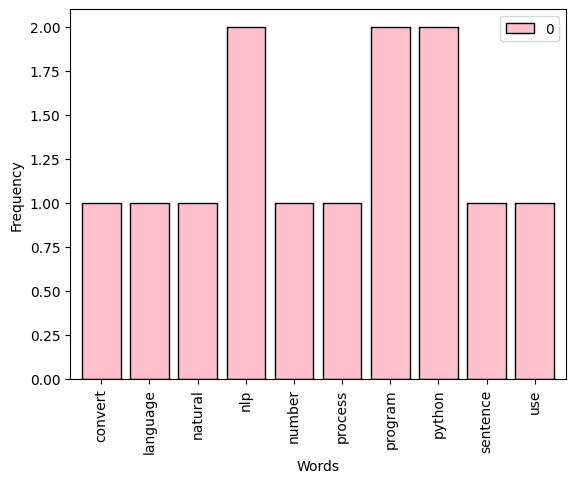

In [ ]:
#Count plot or Bag of words
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

count_mat.T.plot(kind='bar', color='pink', edgecolor='black', width=0.8)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df=pd.read_csv('/content/Tweets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
df_tweet=df[['tweet_id','airline_sentiment','airline','text']]
df_tweet.head()

,tweet_id,airline_sentiment,airline,text
0,570306133677760513,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,570301130888122368,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,570301083672813571,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,570301031407624196,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,570300817074462722,negative,Virgin America,@VirginAmerica and it's a really big bad thing...


In [ ]:
#Steps: lowercasing, removing punctuation and special characters, tokenization, stopwords removal, lemmatization and vectorization.
#visualization: Bag of words, Word cloud.

In [ ]:
#Lowercasing
df_tweet['text']=df_tweet['text'].str.lower()

/tmp/ipython-input-3922756872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tweet['text']=df_tweet['text'].str.lower()


In [ ]:
def remove_punct(text):
  text=re.sub(r"[^a-z\s']",'', text)
  return text

df_tweet['clean_text']=df_tweet['text'].apply(remove_punct)

/tmp/ipython-input-522166890.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tweet['clean_text']=df_tweet['text'].apply(remove_punct)


In [ ]:
df_tweet

,tweet_id,airline_sentiment,airline,text,clean_text
0,570306133677760513,neutral,Virgin America,@virginamerica what @dhepburn said.,virginamerica what dhepburn said
1,570301130888122368,positive,Virgin America,@virginamerica plus you've added commercials t...,virginamerica plus you've added commercials to...
2,570301083672813571,neutral,Virgin America,@virginamerica i didn't today... must mean i n...,virginamerica i didn't today must mean i need ...
3,570301031407624196,negative,Virgin America,@virginamerica it's really aggressive to blast...,virginamerica it's really aggressive to blast ...
4,570300817074462722,negative,Virgin America,@virginamerica and it's a really big bad thing...,virginamerica and it's a really big bad thing ...
...,...,...,...,...,...
14635,569587686496825344,positive,American,@americanair thank you we got on a different f...,americanair thank you we got on a different fl...
14636,569587371693355008,negative,American,@americanair leaving over 20 minutes late flig...,americanair leaving over minutes late flight ...
14637,569587242672398336,neutral,American,@americanair please bring american airlines to...,americanair please bring american airlines to ...
14638,569587188687634433,negative,American,"@americanair you have my money, you change my ...",americanair you have my money you change my fl...


In [ ]:
def tokenize(text):
  sent_tokens=word_tokenize(text)
  return sent_tokens
df_tweet['clean_text']=df_tweet['clean_text'].apply(tokenize)

/tmp/ipython-input-1342333903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tweet['clean_text']=df_tweet['clean_text'].apply(tokenize)


In [ ]:
df_tweet

,tweet_id,airline_sentiment,airline,text,clean_text
0,570306133677760513,neutral,Virgin America,@virginamerica what @dhepburn said.,"[virginamerica, what, dhepburn, said]"
1,570301130888122368,positive,Virgin America,@virginamerica plus you've added commercials t...,"[virginamerica, plus, you, 've, added, commerc..."
2,570301083672813571,neutral,Virgin America,@virginamerica i didn't today... must mean i n...,"[virginamerica, i, did, n't, today, must, mean..."
3,570301031407624196,negative,Virgin America,@virginamerica it's really aggressive to blast...,"[virginamerica, it, 's, really, aggressive, to..."
4,570300817074462722,negative,Virgin America,@virginamerica and it's a really big bad thing...,"[virginamerica, and, it, 's, a, really, big, b..."
...,...,...,...,...,...
14635,569587686496825344,positive,American,@americanair thank you we got on a different f...,"[americanair, thank, you, we, got, on, a, diff..."
14636,569587371693355008,negative,American,@americanair leaving over 20 minutes late flig...,"[americanair, leaving, over, minutes, late, fl..."
14637,569587242672398336,neutral,American,@americanair please bring american airlines to...,"[americanair, please, bring, american, airline..."
14638,569587188687634433,negative,American,"@americanair you have my money, you change my ...","[americanair, you, have, my, money, you, chang..."


In [ ]:
def sw_removal(text):
  filtered_tokens=[word for word in text if word not in sw]
  return filtered_tokens

df_tweet['clean_text']=df_tweet['clean_text'].apply(sw_removal)
df_tweet

/tmp/ipython-input-1777649428.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tweet['clean_text']=df_tweet['clean_text'].apply(sw_removal)


,tweet_id,airline_sentiment,airline,text,clean_text
0,570306133677760513,neutral,Virgin America,@virginamerica what @dhepburn said.,"[virginamerica, dhepburn, said]"
1,570301130888122368,positive,Virgin America,@virginamerica plus you've added commercials t...,"[virginamerica, plus, 've, added, commercials,..."
2,570301083672813571,neutral,Virgin America,@virginamerica i didn't today... must mean i n...,"[virginamerica, n't, today, must, mean, need, ..."
3,570301031407624196,negative,Virgin America,@virginamerica it's really aggressive to blast...,"[virginamerica, 's, really, aggressive, blast,..."
4,570300817074462722,negative,Virgin America,@virginamerica and it's a really big bad thing...,"[virginamerica, 's, really, big, bad, thing]"
...,...,...,...,...,...
14635,569587686496825344,positive,American,@americanair thank you we got on a different f...,"[americanair, thank, got, different, flight, c..."
14636,569587371693355008,negative,American,@americanair leaving over 20 minutes late flig...,"[americanair, leaving, minutes, late, flight, ..."
14637,569587242672398336,neutral,American,@americanair please bring american airlines to...,"[americanair, please, bring, american, airline..."
14638,569587188687634433,negative,American,"@americanair you have my money, you change my ...","[americanair, money, change, flight, n't, answ..."


In [ ]:
def lemmat(text):
  return [lem.lemmatize(i, pos='v') for i in text]
df_tweet['final_text']=df_tweet['clean_text'].apply(lemmat)
df_tweet

In [ ]:
#String of the final column
final_text=' '.join([' '.join(tokens) for tokens in df_tweet['final_text']])
final_text= final_text. replace('unite', '')
final_text= final_text. replace('flight', '')
final_text= final_text. replace('usairway', '')
final_text= final_text. replace("'s", "")
final_text= final_text. replace('jetblue', '')
final_text= final_text. replace("n't", "")
final_text= final_text. replace('southwestair', '')
final_text= final_text. replace('americanair', '')


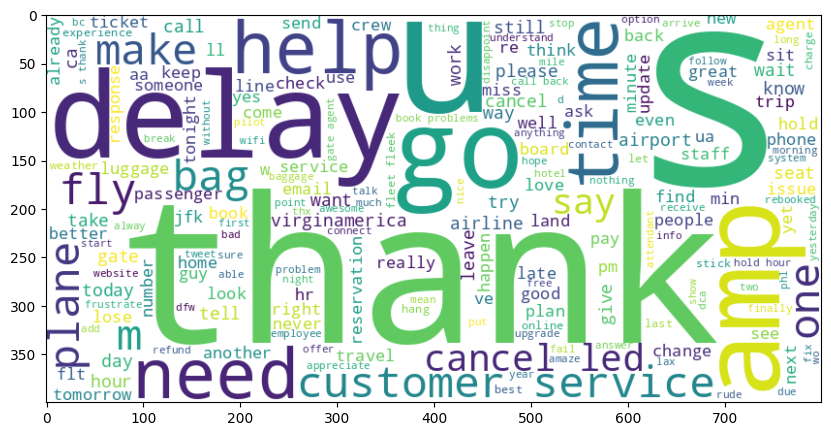

In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(final_text)

plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.show()